In [1]:
import os 
import time 
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy.special import j0
import plotly.graph_objects as go
from iminuit.cost import LeastSquares
from scipy.integrate import fixed_quad

In [2]:
# experimental data
save_folder = 'run7'
n_points = 10000

lower_factor = 0.99
upper_factor = 2 - lower_factor

# Load experimental data
atlas_data = pd.read_csv('../../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
totem_data = pd.read_csv('../../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)

# Function to process data for each experiment
def process_data(data, energy_blocks):
    x_values = []
    y_values = []
    y_errors = []
    
    for start, end in energy_blocks:
        block = data.iloc[start:end] if end is not None else data.iloc[start:]
        x_values.append(block[0].values)
        y_values.append(block[1].values)
        y_errors.append(block[2].values)
    
    return x_values, y_values, y_errors

# Energy ranges for each experiment (7TeV, 8TeV, 13TeV)
atlas_blocks = [(0, 29), (29, 58), (58, None)]
totem_blocks = [(0, 65), (65, 118), (118, None)]

# Process data
x_atlas, y_atlas, yerr_atlas = process_data(atlas_data, atlas_blocks)

# Extract values by energy (index 0=7TeV, 1=8TeV, 2=13TeV)
x_7_atlas, y_7_atlas, yerr_7_atlas = x_atlas[0], y_atlas[0], yerr_atlas[0]
x_8_atlas, y_8_atlas, yerr_8_atlas = x_atlas[1], y_atlas[1], yerr_atlas[1]
x_13_atlas, y_13_atlas, yerr_13_atlas = x_atlas[2], y_atlas[2], yerr_atlas[2]

/tmp/ipykernel_10951/4196082941.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  atlas_data = pd.read_csv('../../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
/tmp/ipykernel_10951/4196082941.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  totem_data = pd.read_csv('../../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)


In [3]:
# setting parameters
b_0 = (33 - 6) / (12 * np.pi)
Lambda = 0.284  # ΛQCD in GeV
gamma_1 = 0.084
gamma_2 = 2.36
rho = 4.0
s0 = 1.0
alpha_prime = 0.25



ensemble_parameters = {
    'atlas': {
        'log': {
            'epsilon': 0.0753,
            'mg': 0.356,
            'a1': 1.373,
            'a2': 2.50
        },
        'pl': {
            'epsilon': 0.0753,
            'mg': 0.421,
            'a1': 1.517,
            'a2': 2.05
        }
    },
    'totem': {
        'log': {
            'epsilon': 0.0892,
            'mg': 0.380,
            'a1': 1.491,
            'a2': 2.77
        },
        'pl':{
            'epsilon': 0.0892,
            'mg': 0.447,
            'a1': 1.689,
            'a2': 1.7
        }
    }
}

ensemble_atlas = 'atlas'  
ensemble_totem = 'totem'

log_model_type = 'log'
pl_model_type = 'pl'   

def get_parameters_with_variations(ensemble_parameters, ensemble_name, model_type, lower_factor=lower_factor, upper_factor=upper_factor):
    # Obtém os parâmetros iniciais
    initial_params = ensemble_parameters[ensemble_name][model_type]
    
    # Cria as variações
    initial_params_low = {k: v * lower_factor for k, v in initial_params.items()}
    initial_params_high = {k: v * upper_factor for k, v in initial_params.items()}
    
    return initial_params, initial_params_low, initial_params_high

# Get parameters for selected configuration
initial_params_pl_atlas = ensemble_parameters[ensemble_atlas][pl_model_type]

# Para Atlas
initial_params_pl_atlas, initial_params_low_pl_atlas, initial_params_high_pl_atlas = \
    get_parameters_with_variations(ensemble_parameters, ensemble_atlas, pl_model_type)




In [4]:
# def model functions 
def m2_log(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return mg ** 2 * ratio ** (-1 - gamma_1)

def m2_pl(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return (mg ** 4 / (q2 + mg ** 2)) * ratio ** (gamma_2 - 1)


def G_p(q2, a1, a2):
    return np.exp(-(a1 * q2 + a2 * q2 ** 2))

def alpha_D(q2, mg, m2_func):
    m2 = m2_func(q2, mg)
    return 1.0 / (b_0 * (q2 + m2) * np.log((q2 + 4 * m2) / (Lambda ** 2)))

def T_1(k, q, phi, mg, a1, a2, m2_func):
    q2 = q
    qk_cos = np.sqrt(q) * k * np.cos(phi)
    qk_plus_squared = q2 / 4 + qk_cos + k ** 2
    qk_minus_squared = q2 / 4 - qk_cos + k ** 2
    alpha_D_plus = alpha_D(qk_plus_squared, mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)
    G0 = G_p(q2, a1, a2)
    return alpha_D_plus * alpha_D_minus * G0 ** 2

def T_2(k, q, phi, mg, a1, a2, m2_func):
    q2 = q 
    qk_cos = np.sqrt(q) * k * np.cos(phi)
    qk_plus_squared = q2 / 4 + qk_cos + k ** 2
    qk_minus_squared = q2 / 4 - qk_cos + k ** 2
    alpha_D_plus = alpha_D(qk_plus_squared, mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)
    factor = q2 + 9 * abs(k ** 2 - q2 / 4)
    G0 = G_p(q2, a1, a2)
    G_minus = G_p(factor, a1, a2)
    return alpha_D_plus * alpha_D_minus * G_minus * (2 * G0 - G_minus)

def integrand(y, x, mg, a1, a2, m2_func, q_val, sqrt_s):
    k = sqrt_s * x 
    phi = 2 * np.pi * y
    jacobian = 2 * np.pi * sqrt_s 
    return k * (T_1(k, q_val, phi, mg, a1, a2, m2_func) - T_2(k, q_val, phi, mg, a1, a2, m2_func)) * jacobian 

def sigma_tot(amp_value, s):
    return amp_value.imag / s * 0.389379323

def amp_calculation(diff_T, s, epsilon, t):
    alpha_pomeron = 1.0 + epsilon + alpha_prime * t
    regge_factor = (s**alpha_pomeron) * 1/(s0**(alpha_pomeron-1))
    return 1j * 8 * regge_factor * diff_T  

def differential_sigma(amp_value, s):
    amp_squared = amp_value.imag * amp_value.imag
    denominator = (16 * np.pi * s**2)
    return amp_squared / denominator * 0.389379323


In [5]:
def full_int(mg, a1, a2, m2_func, q_val, sqrt_s):

    def integrand(y, x, mg, a1, a2, m2_func, q_val):
        k        = sqrt_s * x
        phi      = 2*np.pi*y
        jacobian = 2*np.pi*sqrt_s
        return k*(T_1(k,q_val,phi,mg,a1,a2,m2_func) -
                  T_2(k,q_val,phi,mg,a1,a2,m2_func))*jacobian
    def inner_integral(x):
            return fixed_quad(
                lambda y: integrand(y, x, mg, a1, a2, m2_func, q_val),
                0, 1, n=n_points
            )[0]

    integral_value = fixed_quad(inner_integral, 0, 1, n=n_points)[0]
    
    return integral_value

In [6]:
# def model function
def model_function(x, eps, mg, a1, a2, sqrt_s, model_type='log'):

    # Definindo os parâmetros específicos do modelo
    params = {
        'epsilon': eps,
        'mg': mg,
        'a1': a1,
        'a2': a2
    }
    
    # Escolhendo a massa conforme o modelo
    m2 = m2_log if model_type == 'log' else m2_pl
    
    dif_sigma_lst = []
    
    for q2 in x:
        t = -q2
        
        integral_value = full_int(mg, a1, a2, m2, q2, sqrt_s)

        diff_T = integral_value
        s = sqrt_s ** 2
        amp_value = amp_calculation(diff_T, s, params['epsilon'], t)
        dif_sigma_value = differential_sigma(amp_value, s)
        dif_sigma_lst.append(dif_sigma_value)
    
    return np.array(dif_sigma_lst)

In [7]:
# set cost and minimize
def model_7(x, eps, mg, a1, a2):
    return model_function(x, eps, mg, a1, a2, sqrt_s=7000, model_type='pl')

def model_8(x, eps, mg, a1, a2):
    return model_function(x, eps, mg, a1, a2, sqrt_s=8000, model_type='pl')

def model_13(x, eps, mg, a1, a2):
    return model_function(x, eps, mg, a1, a2, sqrt_s=13000, model_type='pl')


chi2_7  = LeastSquares(x_7_atlas,  y_7_atlas,  yerr_7_atlas,  model_7)
chi2_8  = LeastSquares(x_8_atlas,  y_8_atlas,  yerr_8_atlas,  model_8)
chi2_13 = LeastSquares(x_13_atlas, y_13_atlas, yerr_13_atlas, model_13)


chi2_total = chi2_7 + chi2_8 + chi2_13


minuit_born = Minuit(
    chi2_total,
    mg = 0.421,
    a1 = 1.517,
    a2 = 2.05,
    eps = 0.0753
)

minuit_born.migrad()
minuit_born.hesse()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 25.93 (χ²/ndof = 0.2)      │              Nfcn = 341              │
│ EDM = 3.1e-06 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ eps  │  0.0616   │  0.0022   │            │            │         │         │       │
│ 1 │ mg   │   0.389   │   0.005   │            │            │         │         │       │
│ 2 │ a1   │   1.49    │   0.05    │            │            │         │         │       │
│ 3 │ a2   │   2.16    │   0.31    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────┐
│     │      eps       mg       a1       a2 │
├─────┼─────────────────────────────────────┤
│ eps │ 4.86e-06    10e-6    54e-6  -157e-6 │
│  mg │    10e-6 2.41e-05 0.056e-3 0.100e-3 │
│  a1 │    54e-6 0.056e-3   0.0023  -0.0136 │
│  a2 │  -157e-6 0.100e-3  -0.0136   0.0956 │
└─────┴─────────────────────────────────────┘

In [8]:
# Calculates and plot dif sigma 
def get_dif_sigma(epsilon, mg, a1, a2, mg_model):

    sqrt_s = 7000
    scale = 1  # caso único
    start_q2 = 0.006
    max_q2   = 0.204
    q2_step  = 0.001

    lst_q2 = []
    lst_dif_sigma = []

    q2 = start_q2
    while q2 <= max_q2:
        t = -q2

        integral_value = full_int(mg, a1, a2, mg_model, q2, sqrt_s)


        diff_T = integral_value
        print(diff_T)
        # print(f"q2: {q2}, diff_T: {diff_T}")

        s          = sqrt_s**2
        amp_value  = amp_calculation(diff_T, s, epsilon, t)
        dif_sigma  = differential_sigma(amp_value, s) * scale

        lst_q2.append(q2)
        lst_dif_sigma.append(dif_sigma)

        q2 += q2_step

    return {sqrt_s: (lst_q2, lst_dif_sigma)}

#for pl atlas
dif_sigma_pl_atlas = get_dif_sigma(
    minuit_born.values['eps'],
    minuit_born.values['mg'], 
    minuit_born.values['a1'],
    minuit_born.values['a2'],
    m2_pl
)

dif_sigma_pl_atlas_7_q2 = dif_sigma_pl_atlas[7000][0]
dif_sigma_pl_atlas_7_values = dif_sigma_pl_atlas[7000][1]


def add_differential_trace(fig, x, y, label, color='red', mg_model= 'log', legend=True, size = 4, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width),
        marker=dict(size=size),
        name=f'{label}, {mg_model}',
        showlegend=legend,

    ))

def add_data_trace(fig, x, y, y_error, scale=1.0, color='black', size=4,
                           name=None, show_label=True, mode='markers'):
    fig.add_trace(go.Scatter(
        x=x,
        y=y * scale,
        mode=mode,
        marker=dict(color=color, size=size),
        error_y=dict(
            type='data',
            array=y_error * scale,
            visible=True
        ),
        name=name if show_label else None,
        showlegend=show_label
    ))

fig_atlas = go.Figure()


# for pl atlas
add_differential_trace(fig_atlas, dif_sigma_pl_atlas_7_q2, dif_sigma_pl_atlas_7_values,label='7 TeV', color='blue', mg_model='pl')

#data points
add_data_trace(fig_atlas, x_7_atlas, y_7_atlas, yerr_7_atlas, name='ATLAS 7 TeV', show_label=True, mode='markers')

# Atualiza layout
fig_atlas.update_layout(
    title='dσ/dt vs. |t| - Log and PL models in ATLAS',
    xaxis_title='|t| (GeV²)',
    yaxis_title='dσ/dt (mb/GeV²)',
    yaxis_type='log',
    legend_title='Mass Model',
    plot_bgcolor='white',
    hovermode='x unified'
)

fig_atlas.update_xaxes(gridcolor='lightgray')
fig_atlas.update_yaxes(gridcolor='lightgray')

# fig_atlas.show(renderer='browser')


10.017599690350817
9.9643766716833
9.911395674394367
9.858656320506913
9.806158235346725
9.75390105019654
9.701884399928137
9.650107921304972
9.59857125925256
9.547274057202099
9.49621596148865
9.445396626816779
9.394815705152842
9.344472846531641
9.294367711079502
9.244499959655348
9.194869247968054
9.145475229375851
9.09631756822286
9.047395928599888
8.998709968304835
8.950259338901633
8.902043695189795
8.854062701399554
8.806316015839812
8.758803289225945
8.711524164639133
8.664478283141927
8.617665297751184
8.571084857096936
8.524736600849824
8.478620159702174
8.432735155356001
8.387081206518445
8.341657943771208
8.296464992165026
8.251501966373269
8.206768470706612
8.16226409913497
8.117988435385435
8.073941062993423
8.030121575197636
7.986529556054064
7.943164577897393
7.900026201401917
7.857113975650026
7.814427438208034
7.7719661161307325
7.729729542155432
7.687717251795112
7.645928768174966
7.604363601601603
7.563021249682466
7.521901197452725
7.481002917509453
7.4403258701528

In [9]:
# # PLOT BORN SIGMA TOT =============================================================
# # 
# # =============================================================


data_sigma_tot_atlas = pd.read_csv(
    "../../../../data/sigma_tot_2/ensemble_StRh_atlas.dat",
    delim_whitespace=True,
    header=None,
    nrows=70
)

x_sigma_tot_atlas = data_sigma_tot_atlas[0].to_numpy()
y_sigma_tot_atlas = data_sigma_tot_atlas[1].to_numpy()
y_error_sigma_tot_atlas = data_sigma_tot_atlas[2].to_numpy()

lst_born_amp = []

start_sqrt_s = 1
max_sqrt_s = 13010
step = 100

def add_total_trace(fig, x, y, color='red', label='', line_style='solid', legend=True, size = 3, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width, dash=line_style),
        marker=dict(size=size),
        name = label, 
        showlegend=legend
    ))

def get_sigma_tot(epsilon, mg, a1, a2, mg_model):

    lst_sigma_tot = []
    lst_sqrt_s = []

    sqrt_s = start_sqrt_s

    while sqrt_s <= max_sqrt_s:

        s = sqrt_s ** 2

        integral_value = full_int(mg, a1, a2, mg_model, 0.0, sqrt_s) 

        born_amp = amp_calculation(integral_value, s, epsilon, 0)
        lst_born_amp.append(born_amp)
        
        lst_sigma_tot.append(sigma_tot(
            amp_calculation(integral_value, s, epsilon, 0), s))
        
        lst_sqrt_s.append(sqrt_s)
        sqrt_s += step
    return lst_sigma_tot, lst_sqrt_s

##-----------------------------------------------------------------------------------------------

sigma_tot_pl_atlas = get_sigma_tot(
    minuit_born.values['eps'],
    minuit_born.values['mg'],
    minuit_born.values['a1'],
    minuit_born.values['a2'],
    m2_pl
)

sigma_tot_pl_atlas_values = sigma_tot_pl_atlas[0]
lst_sqrt_s = sigma_tot_pl_atlas[1]



fig = go.Figure()

add_total_trace(fig, lst_sqrt_s, sigma_tot_pl_atlas_values, color='blue', label='PL Atlas', line_style='solid')

#-----------------------------------------------------------------------------------------------
#----

add_data_trace(fig, x_sigma_tot_atlas, y_sigma_tot_atlas, y_error_sigma_tot_atlas, name='ATLAS', show_label=True, mode='markers')

fig.update_layout(
    title = 'σ_tot vs. √s - Ensemble Atlas and Totem in Log and PL model',
    xaxis=dict(
        title='√s [GeV]',
        type='log',
        range=[np.log10(2000), np.log10(14000)],
    ),
    yaxis=dict(
        title='σ_tot [mb]',
        range=[80, 125]
    ),
    showlegend=True,
    legend=dict(
        title='Ensembles'
    ),
    plot_bgcolor='white',
    hovermode='x unified'
)
    
fig.update_xaxes(gridcolor='lightgray')
fig.update_yaxes(gridcolor='lightgray')

# fig.show(renderer="browser")

/tmp/ipykernel_10951/414226233.py:6: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



In [10]:
def full_int(mg, a1, a2, m2_func, q_val, sqrt_s):

    def integrand(y, x, mg, a1, a2, m2_func, q_val):
        k        = sqrt_s * x
        phi      = 2*np.pi*y
        jacobian = 2*np.pi*sqrt_s
        return k*(T_1(k,q_val,phi,mg,a1,a2,m2_func) -
                  T_2(k,q_val,phi,mg,a1,a2,m2_func))*jacobian
    def inner_integral(x):
            return fixed_quad(
                lambda y: integrand(y, x, mg, a1, a2, m2_func, q_val),
                0, 1, n=n_points
            )[0]

    integral_value = fixed_quad(inner_integral, 0, 1, n=n_points)[0]
    
    return integral_value


In [ ]:
# from scipy.integrate import quad  # kept for compatibility if used elsewhere

# lst_chi = []
# lst_amp_eik = []
# lst_diff_sigma = []

# lst_q_integration = np.linspace(0, 0.1, 100)
# lst_b_integration = np.linspace(0, 50, 100)

# # step size for Riemann sum
# dq = lst_q_integration[1] - lst_q_integration[0]

# for b_val in lst_b_integration:

#     chi_sum = 0

#     for q_val in lst_q_integration:

#         q2_val = q_val**2
#         sqrt_s = 7000

#         s = sqrt_s ** 2
#         t = -q2_val

#         # diff_t = full_int(
#         #     ensemble_parameters['atlas']['pl']['mg'],
#         #     ensemble_parameters['atlas']['pl']['a1'],
#         #     ensemble_parameters['atlas']['pl']['a2'],
#         #     m2_pl,
#         #     q2_val,
#         #     sqrt_s
#         # )

#         diff_t = full_int(
#             minuit_born.values['mg'],
#             minuit_born.values['a1'],
#             minuit_born.values['a2'],
#             m2_pl,
#             q2_val,
#             sqrt_s
#         )
#         # print(diff_t)

#         born_amp = amp_calculation(diff_t, s, minuit_born.values['eps'], t)
#         # born_amp = amp_calculation(diff_t, s, ensemble_parameters['atlas']['pl']['epsilon'], t)
#         # print(born_amp)
#         chi_val = (1/s) * q_val * j0(b_val * q_val) * born_amp

#         # Riemann sum contribution
#         chi_sum += chi_val * dq

#     print(chi_sum)

#     lst_chi.append(chi_sum)


1.1842830381823908j
1.1839079180871392j
1.1827830369621402j
1.1809098315220845j
1.1782906937342639j
1.1749289669876146j
1.1708289407390033j
1.1659958436463977j
1.1604358352012445j
1.1541559958750796j
1.1471643157980644j
1.1394696819897758j
1.1310818641651426j
1.1220114991410075j
1.1122700738712465j
1.101869907140865j
1.0908241299518318j
1.0791466646357741j
1.0668522027308844j
1.053956181662579j
1.0404747602695625j
1.0264247932189723j
1.0118238043562229j
0.996689959037023j
0.9810420354908076j
0.9648993952664981j
0.9482819528130657j
0.9312101442488655j
0.913704895375062j
0.8957875889897419j
0.877480031560451j
0.858804419313971j
0.839783303803042j
0.8204395570105995j
0.8007963360527739j
0.7808770475425066j
0.760705311676095j
0.740304926105357j
0.7196998296583157j
0.6989140659714442j
0.6779717470965106j
0.6568970171449187j
0.6357140160322476j
0.6144468433853021j
0.5931195226735319j
0.5717559656261005j
0.5503799369951672j
0.5290150197251487j
0.5076845805868136j
0.48641173633400386j
0.465219

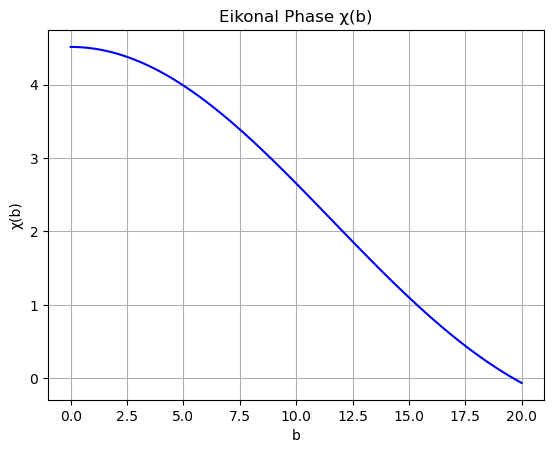

In [71]:
from scipy.integrate import fixed_quad
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt

lst_chi = []
lst_b_integration = np.linspace(0, 20, 100)

sqrt_s = 7000
s = sqrt_s ** 2
q_min, q_max = 0, 0.2

# Loop over b points (so we can store chi(b) values)
for b_val in lst_b_integration:

    # Inner integration over q using fixed_quad
    def integrand_q(q_val):
        q2_val = q_val ** 2
        t = -q2_val

        diff_t = full_int(
            minuit_born.values['mg'],
            minuit_born.values['a1'],
            minuit_born.values['a2'],
            m2_pl,
            q2_val,
            sqrt_s
        )

        born_amp = amp_calculation(diff_t, s, minuit_born.values['eps'], t)
        return (1/s) * q_val * j0(b_val * q_val) * born_amp

    chi_val, _ = fixed_quad(integrand_q, q_min, q_max, n=10000)
    lst_chi.append(chi_val)

# Now integrate chi(b) over b also using fixed_quad
def integrand_b(b_val):
    def integrand_q(q_val):
        q2_val = q_val ** 2
        t = -q2_val

        diff_t = full_int(
            minuit_born.values['mg'],
            minuit_born.values['a1'],
            minuit_born.values['a2'],
            m2_pl,
            q2_val,
            sqrt_s
        )

        born_amp = amp_calculation(diff_t, s, minuit_born.values['eps'], t)
        return (1/s) * q_val * j0(b_val * q_val) * born_amp

    chi_val, _ = fixed_quad(integrand_q, q_min, q_max, n=10000)
    return chi_val

# Full integration over b (for reference or further use)
chi_total, _ = fixed_quad(integrand_b, 0, 20, n=10000)

# Plot chi(b)
plt.plot(lst_b_integration, np.imag(lst_chi), color='blue')
plt.xlabel('b')
plt.ylabel('χ(b)')
plt.title('Eikonal Phase χ(b)')
plt.grid(True)
plt.show()


In [51]:
lst_chi_imag = [chi.imag for chi in lst_chi]
print(lst_chi)

[np.complex128(8.979802626724293j)]


In [52]:
fig_chi = go.Figure()

add_total_trace(fig_chi, lst_b_integration, lst_chi_imag, color='red', line_style='solid')

fig_chi.update_layout(
    title = r'$Im(\chi) \quad \text{vs.} \quad b \quad \text{(fixed sqrt(s) = 7000 GeV)}$',
    xaxis=dict(
        title='b'
    ),

    showlegend=True,
    legend=dict(
        title=r'$Im(\chi)$'
    ),
    plot_bgcolor='white',
    hovermode='x unified'
)
    
fig_chi.update_xaxes(gridcolor='lightgray')
fig_chi.update_yaxes(gridcolor='lightgray')

fig_chi.show(renderer="browser")
# fig_chi.write_image('../../../../results/eikonal/b_values_plots/chi_b.pdf', width=1200, height=600)
# fig_eik.write_html('chi_sum.html')


Opening in existing browser session.
